# 05. Integration — Semantic Analysis + Sentiment Analysis

Combines the outputs of all previous notebooks into a single master dataframe
and surfaces cross-cutting findings for the paper.

**Inputs:**
- `../Data/Processed/ushmm_full_with_bert.csv` — VADER + BERT scores (all 10,116 reviews)
- `../Data/Processed/ushmm_semantic_tagged.csv` — semantic category tags (all 10,116 reviews)

**Output:** `../Data/Processed/ushmm_master.csv` — single merged dataset

## Key Questions
1. Which semantic categories show the highest memorial paradox rates?
2. Do visitors in the Emo-/Eval+ quadrant engage differently with TJ themes?
3. How do BERT and VADER scores vary across semantic categories?
4. Does group type or geography shape the sentiment-semantics relationship?
5. What does the overlap of Reflection/Suggestions + negative emotional tone tell us?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

## 1. Build Master Dataset

In [3]:
# Load sentiment data (VADER + BERT)
sent = pd.read_csv("../Data/Processed/ushmm_full_with_bert.csv")

# Load semantic tags
sem = pd.read_csv("../Data/Processed/ushmm_semantic_tagged.csv")

# Parse pipe-separated categories back into lists
sem["content_cats"] = sem["content_cats_str"].fillna("").apply(
    lambda x: x.split("|") if x else []
)

print("Sentiment df:", sent.shape)
print("Semantic df:", sem.shape)

Sentiment df: (10116, 9)
Semantic df: (10116, 8)


In [4]:
df = sent.copy()
df["content_cats"] = sem["content_cats"].values
df["content_cats_str"] = sem["content_cats_str"].values
df["num_content_cats"] = sem["num_content_cats"].values

df["content_cats"] = df["content_cats"].apply(
    lambda x: x if isinstance(x, list) else []
)
df["num_content_cats"] = df["num_content_cats"].fillna(0).astype(int)

print(f"Master dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Master dataset: (10116, 12)
Columns: ['likes', 'rating', 'review_text', 'group_type', 'reviewer_location', 'emo_vader', 'eval_vader', 'emo_eval_bucket', 'bert_score', 'content_cats', 'content_cats_str', 'num_content_cats']


In [5]:
# Quick sanity check
print("Reviews with at least one semantic category:",
      df["num_content_cats"].gt(0).sum())
print("Reviews with BERT score:",
      df["bert_score"].notna().sum())
print("Reviews with emo_eval_bucket:",
      df["emo_eval_bucket"].notna().sum())
print("\nEmo/Eval quadrant distribution:")
print(df["emo_eval_bucket"].value_counts())

Reviews with at least one semantic category: 8609
Reviews with BERT score: 10116
Reviews with emo_eval_bucket: 10116

Emo/Eval quadrant distribution:
emo_eval_bucket
Emo+ / Eval+       6461
Mixed / Neutral    3076
Emo- / Eval+        342
Emo- / Eval-        237
Name: count, dtype: int64


## 2. Semantic Category × Sentiment Quadrant

For each semantic category, what share of reviews fall into each
emo/eval quadrant? The Emo-/Eval+ share is the memorial paradox rate.

In [6]:
# Explode so each row is one (review, category) pair
df_e = (
    df[df["num_content_cats"] > 0]
    .explode("content_cats")
    .dropna(subset=["content_cats", "emo_eval_bucket"])
    .reset_index(drop=True)
)
df_e = df_e[df_e["content_cats"].str.strip() != ""]

# Cross-tab: category × quadrant (row percentages)
cross = pd.crosstab(df_e["content_cats"], df_e["emo_eval_bucket"])
cross_pct = (pd.crosstab(df_e["content_cats"], df_e["emo_eval_bucket"],
                         normalize="index") * 100).round(1)

print("Raw counts (category × quadrant):")
print(cross)
print("\nRow percentages:")
print(cross_pct)

Raw counts (category × quadrant):
emo_eval_bucket             Emo+ / Eval+  Emo- / Eval+  Emo- / Eval-  \
content_cats                                                           
Comparison / Other Museums           417            17            24   
Learning / Understanding            2088           116            52   
Learning Context (General)          4427           248           143   
Motivation / Why Visit               308            11            12   
Prior Knowledge                      103             4             4   
Reflection / Suggestions            2345           120            49   

emo_eval_bucket             Mixed / Neutral  
content_cats                                 
Comparison / Other Museums              175  
Learning / Understanding                854  
Learning Context (General)             2057  
Motivation / Why Visit                  115  
Prior Knowledge                          40  
Reflection / Suggestions               1102  

Row percentages:
emo

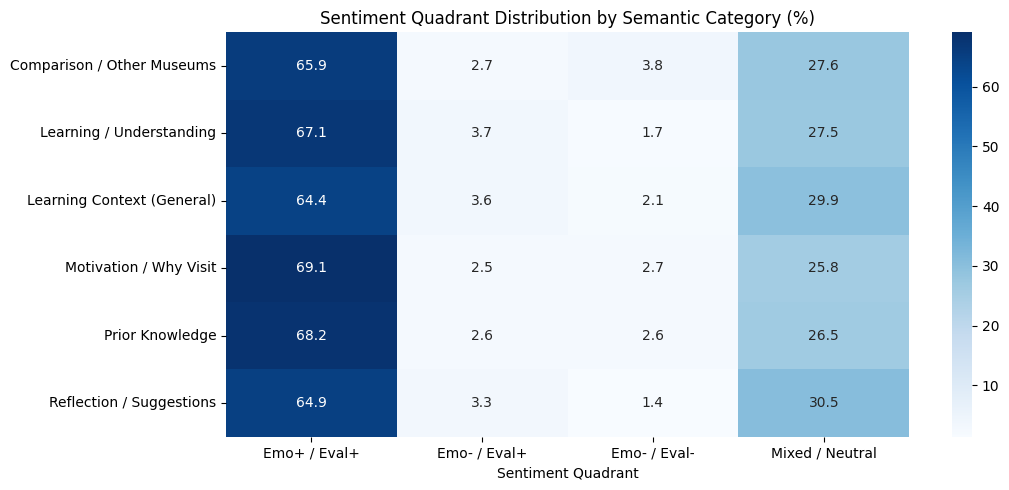

In [7]:
# Heatmap: % of reviews in each quadrant per semantic category
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cross_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Sentiment Quadrant Distribution by Semantic Category (%)")
ax.set_xlabel("Sentiment Quadrant")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../Outputs/Figures/integration_category_quadrant_heatmap.png", dpi=150)
plt.show()

## 3. Memorial Paradox Rate by Semantic Category

Which categories show the highest rate of Emo-/Eval+ reviews?
These are visitors who process emotional negativity while positively
evaluating the museum — the core TJ finding.

In [8]:
paradox_rate = (
    df_e.assign(is_paradox=df_e["emo_eval_bucket"] == "Emo- / Eval+")
    .groupby("content_cats")["is_paradox"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "paradox_n", "mean": "paradox_rate", "count": "total"})
    .assign(paradox_pct=lambda x: (x["paradox_rate"] * 100).round(1))
    .sort_values("paradox_pct", ascending=False)
)
print("Memorial Paradox rate by semantic category:")
print(paradox_rate[["total", "paradox_n", "paradox_pct"]])

Memorial Paradox rate by semantic category:
                            total  paradox_n  paradox_pct
content_cats                                             
Learning / Understanding     3110        116          3.7
Learning Context (General)   6875        248          3.6
Reflection / Suggestions     3616        120          3.3
Comparison / Other Museums    633         17          2.7
Prior Knowledge               151          4          2.6
Motivation / Why Visit        446         11          2.5


## 4. BERT Score by Semantic Category

In [9]:
bert_by_cat = (
    df_e.dropna(subset=["bert_score"])
    .groupby("content_cats")["bert_score"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
    .sort_values("mean")
)
print("BERT score by semantic category:")
print(bert_by_cat)

BERT score by semantic category:
                            count   mean  median    std
content_cats                                           
Prior Knowledge               151  0.592   0.995  0.777
Comparison / Other Museums    633  0.603   0.997  0.770
Learning Context (General)   6875  0.701   0.998  0.685
Motivation / Why Visit        446  0.711   0.998  0.674
Learning / Understanding     3110  0.763   0.999  0.620
Reflection / Suggestions     3616  0.787   0.999  0.587


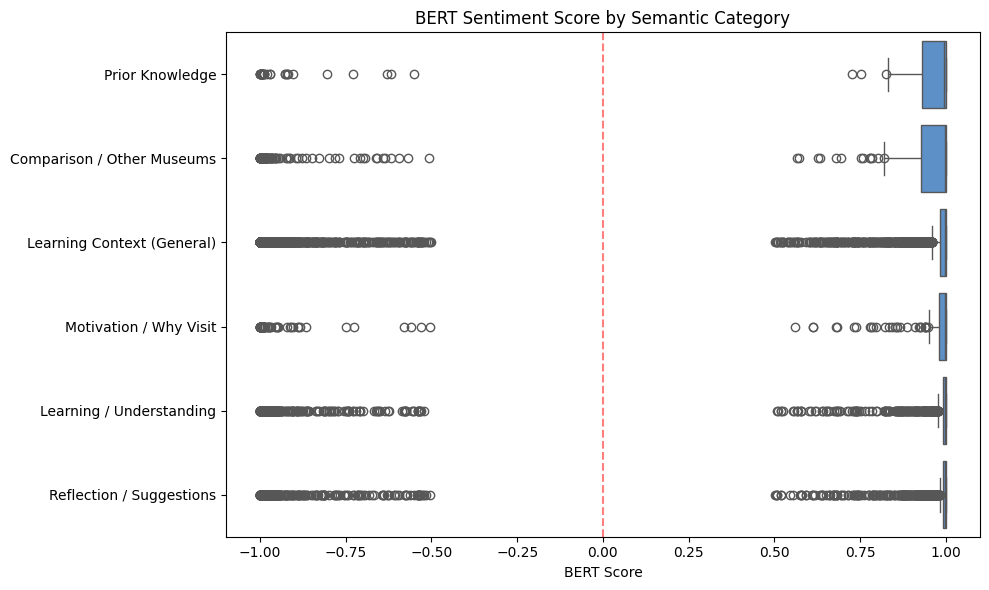

In [10]:
# Boxplot: BERT score distribution per category
fig, ax = plt.subplots(figsize=(10, 6))
order = bert_by_cat.index.tolist()
sns.boxplot(data=df_e.dropna(subset=["bert_score"]),
            y="content_cats", x="bert_score",
            order=order, orient="h", color="#4a90d9", ax=ax)
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
ax.set_title("BERT Sentiment Score by Semantic Category")
ax.set_xlabel("BERT Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../Outputs/Figures/integration_bert_by_category.png", dpi=150)
plt.show()

## 5. The Reflection/Suggestions + Emo- Combination

Visitors who make normative prescriptions ("everyone should visit",
"never forget") while expressing emotional negativity are the clearest
example of the memorial paradox — and the strongest TJ signal in the data.

In [11]:
# Reviews that match Reflection/Suggestions AND are in Emo-/Eval+ quadrant
reflection_paradox = df[
    df["content_cats"].apply(lambda x: "Reflection / Suggestions" in x) &
    (df["emo_eval_bucket"] == "Emo- / Eval+")
]

reflection_total = df[
    df["content_cats"].apply(lambda x: "Reflection / Suggestions" in x)
]

print(f"Reflection/Suggestions reviews: {len(reflection_total)}")
print(f"Of those, Emo-/Eval+ (Memorial Paradox): {len(reflection_paradox)} "
      f"({len(reflection_paradox)/len(reflection_total)*100:.1f}%)")

print("\nExample Reflection + Memorial Paradox reviews:")
for _, r in reflection_paradox.head(3).iterrows():
    print(f"\n  ★{int(r['rating'])} | {r['group_type']} | {r['reviewer_location']}")
    print(f"  emo={r['emo_vader']:.2f}, eval={r['eval_vader']:.2f}, bert={r['bert_score']:.2f}")
    print(f"  {str(r['review_text'])[:350]}...")

Reflection/Suggestions reviews: 3616
Of those, Emo-/Eval+ (Memorial Paradox): 120 (3.3%)

Example Reflection + Memorial Paradox reviews:

  ★5 | FAMILY | Slidell, Louisiana
  emo=-0.33, eval=0.32, bert=1.00
  Visited with wife and our 13 & 11 y/o. Although wife and I thought we knew and understood a lot about this terrible time in history, we realized how little we actually knew. It was very impactful to us, and surprisingly to our children also. Wasnt sure how theyd react. That were very interested in the entirety of this museum. The actual footage a...

  ★5 | NONE | Mountain View, California
  emo=-0.57, eval=0.82, bert=1.00
  Not an easy subject to read about, but I feel it is important to learn about the history of events to teach others and make sure that horrific things like this never happen again.  I was somewhat familiar with the Holocaust, but this really opens your eyes to what happened during that terrible time, and how the US could've possibly done more to pre...

  ★5 

## 6. Group Type Analysis

In [12]:
# Sentiment scores by group type
print("Mean sentiment by group type:")
print(df.groupby("group_type")[["emo_vader", "eval_vader", "bert_score"]]
      .mean().round(3))

Mean sentiment by group type:
            emo_vader  eval_vader  bert_score
group_type                                   
BUSINESS        0.266       0.450       0.797
COUPLES         0.268       0.459       0.654
FAMILY          0.327       0.490       0.660
FRIENDS         0.324       0.498       0.726
NONE            0.299       0.463       0.645
SOLO            0.300       0.481       0.677


In [13]:
# Memorial paradox rate by group type
paradox_by_group = (
    df.dropna(subset=["group_type", "emo_eval_bucket"])
    .assign(is_paradox=df["emo_eval_bucket"] == "Emo- / Eval+")
    .groupby("group_type")["is_paradox"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "paradox_n", "mean": "paradox_rate", "count": "total"})
    .assign(paradox_pct=lambda x: (x["paradox_rate"] * 100).round(1))
    .sort_values("paradox_pct", ascending=False)
)
print("Memorial Paradox rate by group type:")
print(paradox_by_group[["total", "paradox_n", "paradox_pct"]])

Memorial Paradox rate by group type:
            total  paradox_n  paradox_pct
group_type                               
BUSINESS      408         15          3.7
COUPLES      2663         96          3.6
FAMILY       3209        115          3.6
NONE         1303         42          3.2
SOLO          820         26          3.2
FRIENDS      1332         41          3.1


## 7. Geographic Analysis — Domestic vs. International

In [14]:
# Flag domestic (US) vs international reviewers
# US locations contain state names or 'United States'
us_states = [
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado",
    "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
    "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
    "Maine","Maryland","Massachusetts","Michigan","Minnesota",
    "Mississippi","Missouri","Montana","Nebraska","Nevada",
    "New Hampshire","New Jersey","New Mexico","New York",
    "North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
    "Pennsylvania","Rhode Island","South Carolina","South Dakota",
    "Tennessee","Texas","Utah","Vermont","Virginia","Washington",
    "West Virginia","Wisconsin","Wyoming","District of Columbia"
]

def is_us(loc):
    if pd.isna(loc):
        return None
    loc_str = str(loc)
    return any(state in loc_str for state in us_states)

df["is_domestic"] = df["reviewer_location"].apply(is_us)

domestic_counts = df["is_domestic"].value_counts(dropna=False)
print("Domestic (US):", domestic_counts.get(True, 0))
print("International:", domestic_counts.get(False, 0))
print("Unknown/missing:", domestic_counts.get(None, 0))

Domestic (US): 6167
International: 1613
Unknown/missing: 2336


In [15]:
# Sentiment comparison: domestic vs international
geo = df.dropna(subset=["is_domestic"])
print("Mean sentiment — domestic vs international:")
print(geo.groupby("is_domestic")[["emo_vader", "eval_vader", "bert_score", "rating"]]
      .mean().round(3)
      .rename(index={True: "Domestic (US)", False: "International"}))

Mean sentiment — domestic vs international:
               emo_vader  eval_vader  bert_score  rating
is_domestic                                             
International      0.316       0.491       0.715   4.680
Domestic (US)      0.297       0.475       0.667   4.726


In [16]:
# Memorial paradox rate: domestic vs international
paradox_geo = (
    geo.dropna(subset=["emo_eval_bucket"])
    .assign(is_paradox=geo["emo_eval_bucket"] == "Emo- / Eval+")
    .groupby("is_domestic")["is_paradox"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "paradox_n", "mean": "paradox_rate", "count": "total"},
            index={True: "Domestic", False: "International"})
    .assign(paradox_pct=lambda x: (x["paradox_rate"] * 100).round(1))
)
print("Memorial Paradox rate — domestic vs international:")
print(paradox_geo[["total", "paradox_n", "paradox_pct"]])

Memorial Paradox rate — domestic vs international:
               total  paradox_n  paradox_pct
is_domestic                                 
International   1613         56          3.5
Domestic        6167        220          3.6


## 8. Summary Table — Paper-Ready Findings

In [17]:
# Master summary: per category — n, mean rating, mean BERT, paradox rate
summary = (
    df_e.dropna(subset=["bert_score", "emo_eval_bucket"])
    .assign(is_paradox=lambda x: x["emo_eval_bucket"] == "Emo- / Eval+")
    .groupby("content_cats")
    .agg(
        n=("review_text", "count"),
        mean_rating=("rating", "mean"),
        mean_bert=("bert_score", "mean"),
        mean_emo_vader=("emo_vader", "mean"),
        mean_eval_vader=("eval_vader", "mean"),
        paradox_pct=("is_paradox", lambda x: round(x.mean() * 100, 1))
    )
    .round(3)
    .sort_values("paradox_pct", ascending=False)
)
print("Master summary table:")
print(summary)

Master summary table:
                               n  mean_rating  mean_bert  mean_emo_vader  \
content_cats                                                               
Learning / Understanding    3110        4.756      0.763           0.345   
Learning Context (General)  6875        4.723      0.701           0.309   
Reflection / Suggestions    3616        4.790      0.787           0.313   
Comparison / Other Museums   633        4.597      0.603           0.329   
Prior Knowledge              151        4.669      0.592           0.357   
Motivation / Why Visit       446        4.711      0.711           0.379   

                            mean_eval_vader  paradox_pct  
content_cats                                              
Learning / Understanding              0.523          3.7  
Learning Context (General)            0.493          3.6  
Reflection / Suggestions              0.494          3.3  
Comparison / Other Museums            0.502          2.7  
Prior Knowledge

## 9. Export Master Dataset

In [18]:
# Convert content_cats list back to pipe-separated string for CSV
df["content_cats_str"] = df["content_cats"].apply(
    lambda x: "|".join(x) if isinstance(x, list) else ""
)

df.to_csv("../Data/Processed/ushmm_master.csv", index=False)
print(f"Saved master dataset: {len(df)} rows → ../Data/Processed/ushmm_master.csv")
print(f"Columns: {df.columns.tolist()}")

Saved master dataset: 10116 rows → ../Data/Processed/ushmm_master.csv
Columns: ['likes', 'rating', 'review_text', 'group_type', 'reviewer_location', 'emo_vader', 'eval_vader', 'emo_eval_bucket', 'bert_score', 'content_cats', 'content_cats_str', 'num_content_cats', 'is_domestic']


In [19]:
from itertools import combinations
combos = Counter()
for cats in df["content_cats"]:
    if isinstance(cats, list) and len(cats) >= 2:
        for a, b in combinations(sorted(cats), 2):
            combos[(a,b)] += 1

for pair, n in sorted(combos.items(), key=lambda x: -x[1])[:5]:
    print(f"{pair[0]} + {pair[1]}: {n} ({n/len(df)*100:.0f}%)")

Learning Context (General) + Reflection / Suggestions: 2552 (25%)
Learning / Understanding + Learning Context (General): 2282 (23%)
Learning / Understanding + Reflection / Suggestions: 1215 (12%)
Comparison / Other Museums + Learning Context (General): 505 (5%)
Learning Context (General) + Motivation / Why Visit: 330 (3%)
